In [18]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

from sheet1 import PCA

In [3]:
data = loadmat("problem_set1/data/usps.mat")

In [5]:
X = data["data_patterns"].T
y = data["data_labels"].T.argmax(axis=1)

In [6]:
def visualize_all_principal_values(X):
    pca = PCA(X)

    plt.figure()
    plt.bar(np.arange(len(pca.D)), pca.D)
    plt.title("All principal values")
    plt.xlabel("Component")
    plt.ylabel("Eigenvalue")
    plt.show()

def visualize_top25_principal_values(X):
    pca = PCA(X)

    plt.figure()
    plt.bar(np.arange(25), pca.D[:25])
    plt.title("Top 25 principal values")
    plt.xlabel("Component")
    plt.ylabel("Eigenvalue")
    plt.show()

def visualize_first_5_principal_directions(X):
    pca = PCA(X)

    fig, axes = plt.subplots(1, 5, figsize=(12, 3))

    for i in range(5):
        img = pca.U[:, i].reshape(16, 16)
        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(f"PC {i+1}")
        axes[i].axis("off")

    plt.show()

In [7]:
sigma_moderately_noisy = 0.2
X_moderately_noisy = X + sigma_moderately_noisy * np.random.randn(*X.shape)

sigma_very_noisy = 0.5
X_very_noisy = X + sigma_very_noisy * np.random.randn(*X.shape)

rng = np.random.default_rng(42)

sigma_outliers = 50.0
idxs = rng.choice(X.shape[0], 5, replace=False)
X_outliers = X.copy()
X_outliers[idxs] += sigma_outliers * rng.standard_normal((5, X.shape[1]))
idxs

array([1551,  880, 1312,  178,  869])

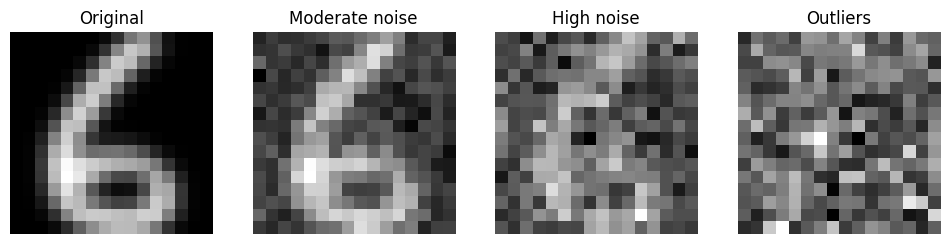

In [8]:
idx = 1551

plt.figure(figsize=(12, 3))

# Original
plt.subplot(1, 4, 1)
plt.imshow(X[idx].reshape(16, 16), cmap='gray')
plt.title("Original")
plt.axis('off')

# Moderate noise
plt.subplot(1, 4, 2)
plt.imshow(X_moderately_noisy[idx].reshape(16, 16), cmap='gray')
plt.title("Moderate noise")
plt.axis('off')

# High noise
plt.subplot(1, 4, 3)
plt.imshow(X_very_noisy[idx].reshape(16, 16), cmap='gray')
plt.title("High noise")
plt.axis('off')

# Outliers (check if first image is outlier or not)
plt.subplot(1, 4, 4)
plt.imshow(X_outliers[idx].reshape(16, 16), cmap='gray')
plt.title("Outliers")
plt.axis('off')

plt.show()

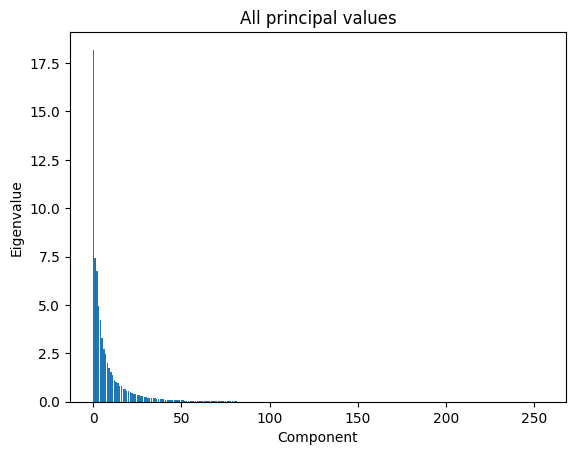

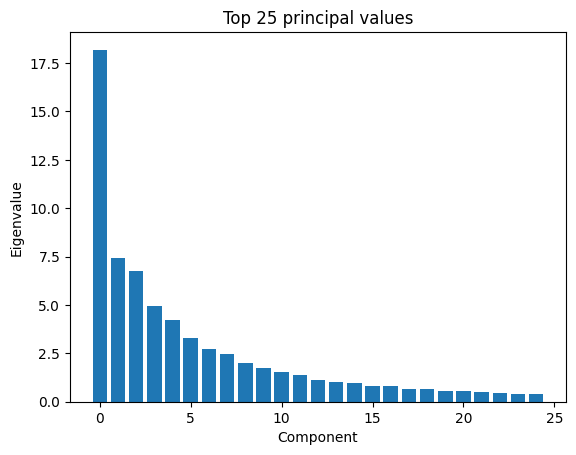

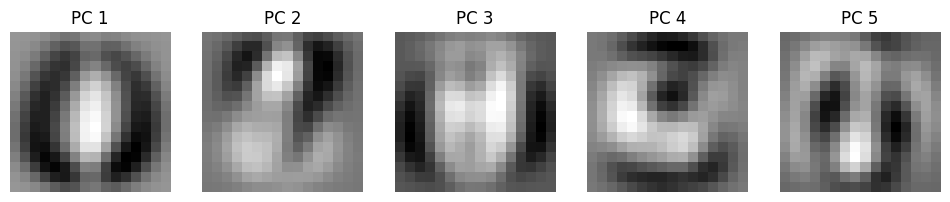

In [9]:
visualize_all_principal_values(X)
visualize_top25_principal_values(X)
visualize_first_5_principal_directions(X)

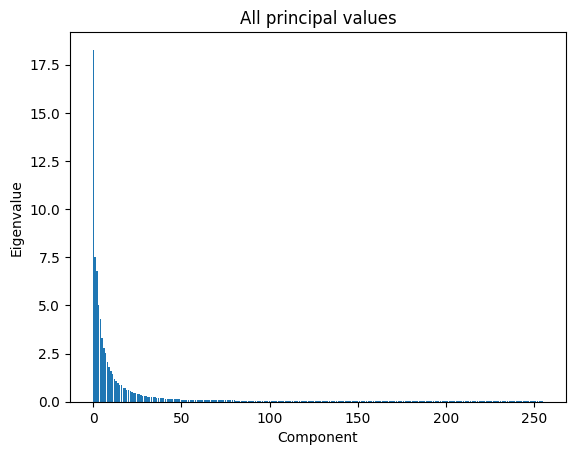

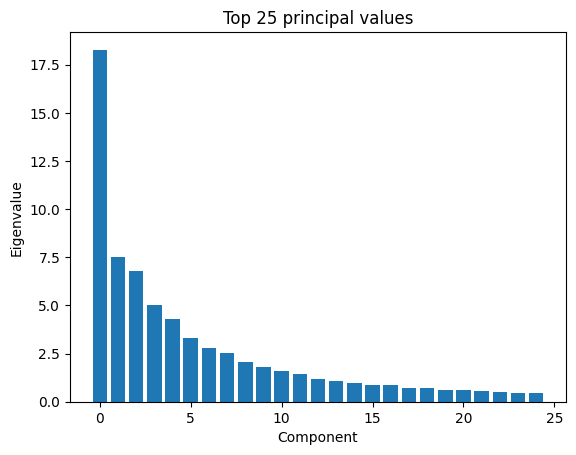

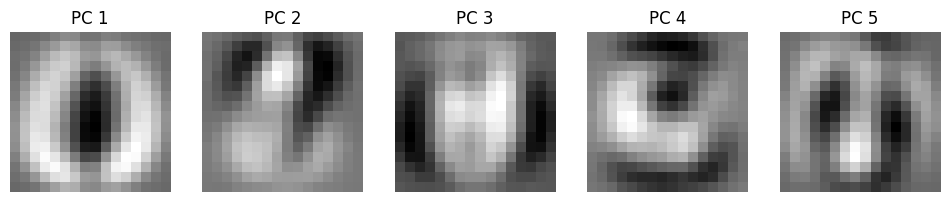

In [10]:
visualize_all_principal_values(X_moderately_noisy)
visualize_top25_principal_values(X_moderately_noisy)
visualize_first_5_principal_directions(X_moderately_noisy)

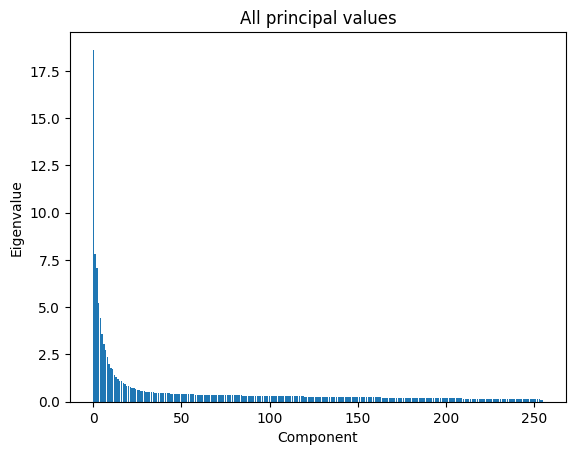

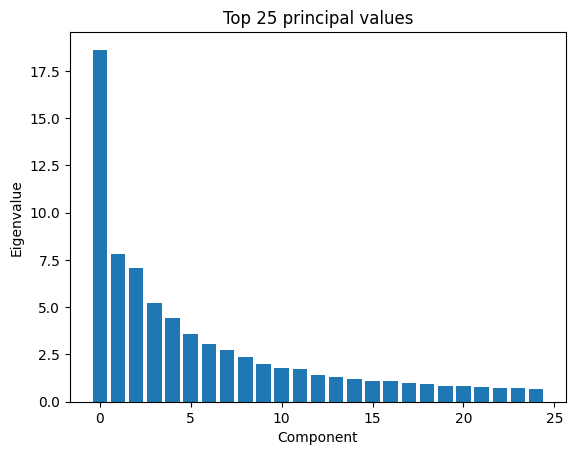

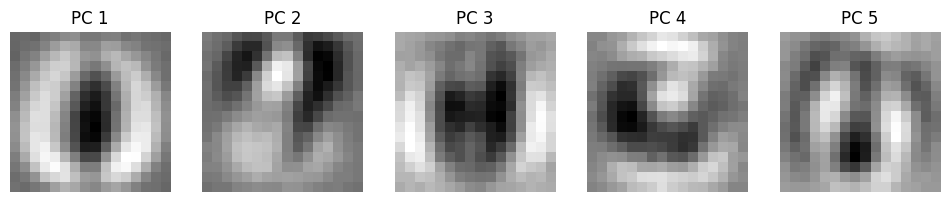

In [11]:
visualize_all_principal_values(X_very_noisy)
visualize_top25_principal_values(X_very_noisy)
visualize_first_5_principal_directions(X_very_noisy)

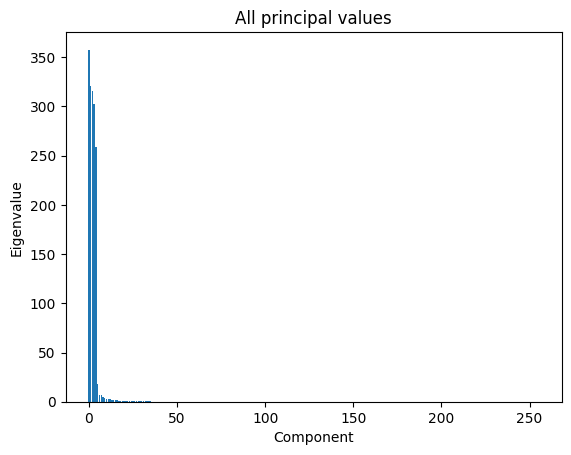

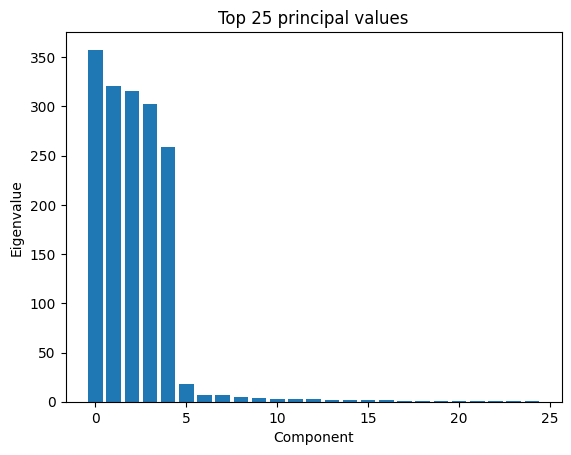

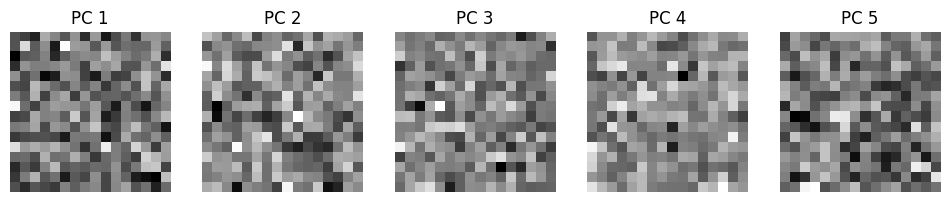

In [12]:
visualize_all_principal_values(X_outliers)
visualize_top25_principal_values(X_outliers)
visualize_first_5_principal_directions(X_outliers)

In [13]:
def plot_denoize(X, X_noisy, idx, ms):
    original = X[idx]
    noisy = X_noisy[idx]
    pca = PCA(X_noisy)

    denoised_images = [pca.denoise(X_noisy, m)[idx] for m in ms]

    plt.figure(figsize=(18, 3))

    # Original
    plt.subplot(1, len(ms) + 2, 1)
    plt.imshow(original.reshape(16, 16), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    plt.subplot(1, len(ms) + 2, 2)
    plt.imshow(noisy.reshape(16, 16), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised for different m
    for i, (m, img) in enumerate(zip(ms, denoised_images)):
        plt.subplot(1, len(ms) + 2, i + 3)
        plt.imshow(img.reshape(16, 16), cmap='gray')
        plt.title(f"m={m}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

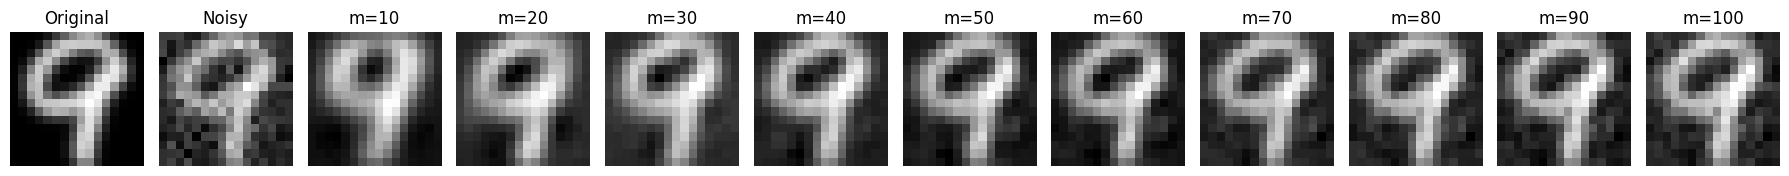

In [14]:
idx = 0    
ms = list(range(10, 101, 10))

plot_denoize(X, X_moderately_noisy, idx, ms)

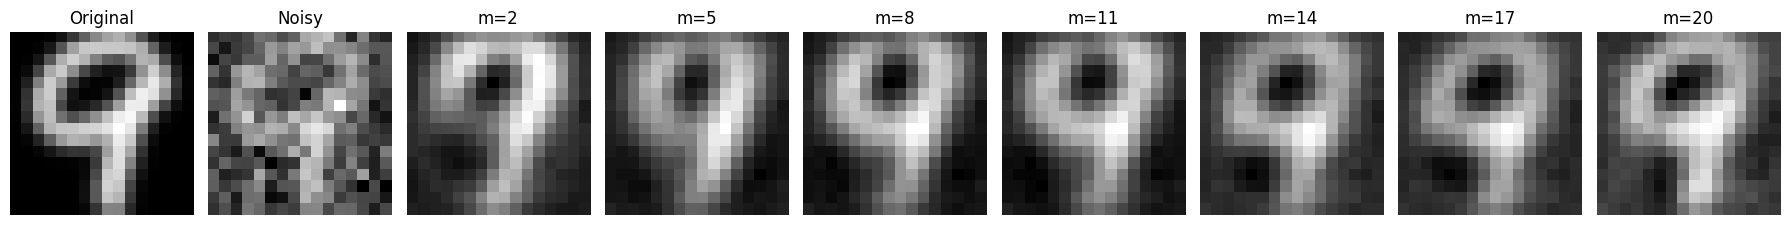

In [15]:
idx = 0
ms = list(range(2, 21, 3))

plot_denoize(X, X_very_noisy, idx, ms)

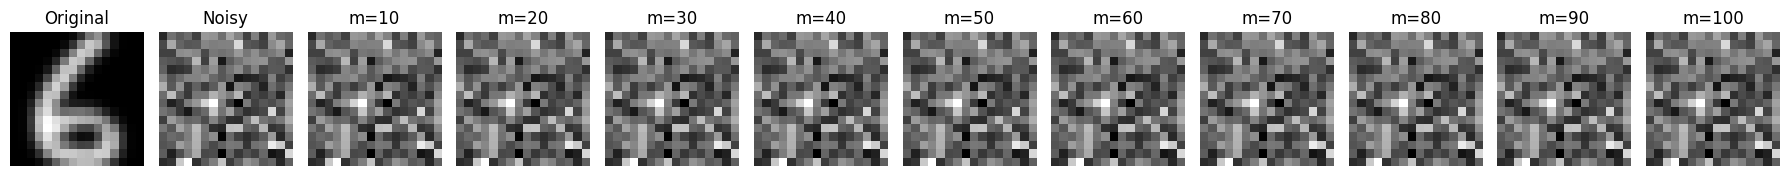

In [16]:
idx = 1551
ms = list(range(10, 101, 10))

plot_denoize(X, X_outliers, idx, ms)

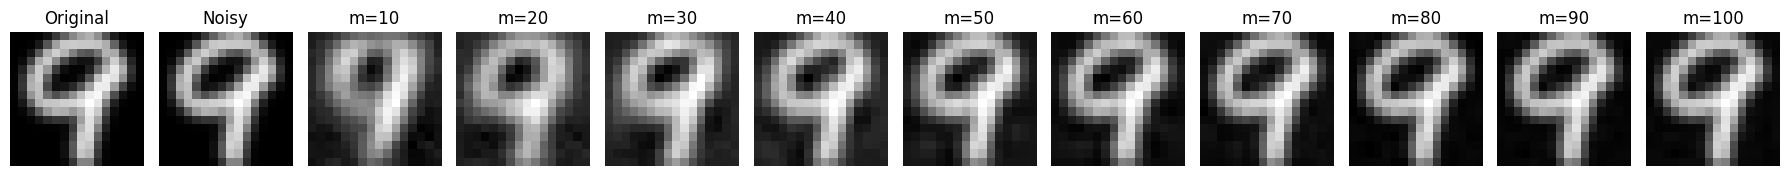

In [17]:
idx = 0
ms = list(range(10, 101, 10))

plot_denoize(X, X_outliers, idx, ms)